# M4/T1 Homework: PubMed RAG по теме Supplements

In [1]:
import gc
import json
import os
import random
import re
import time
import warnings
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from Bio import Entrez, Medline
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from rapidfuzz import fuzz
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from transformers.utils import logging as hf_logging

try:
    from transformers import BitsAndBytesConfig
except Exception:
    BitsAndBytesConfig = None

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 140)

hf_logging.set_verbosity_error()

# Конфиг под RTX 3060 Ti 8GB:
# основной вариант — 7B в 4-bit; fallback — 3B в fp16/fp32
HEAVY_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
USE_4BIT = True


def unload_pipelines(*names: str) -> None:
    g = globals()
    for name in names:
        if name in g:
            del g[name]
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        if hasattr(torch.cuda, "ipc_collect"):
            torch.cuda.ipc_collect()


def build_textgen_pipeline(model_name: str, use_4bit: bool = True):
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    resolved_model = model_name
    quant_cfg = None

    if use_4bit:
        if BitsAndBytesConfig is None:
            print("BitsAndBytes недоступен: fallback на модель поменьше без 4-bit.")
            resolved_model = FALLBACK_MODEL_NAME
        else:
            quant_cfg = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=dtype,
            )

    model_kwargs = {
        "device_map": "auto",
        "torch_dtype": dtype,
        "low_cpu_mem_usage": True,
    }
    if quant_cfg is not None:
        model_kwargs["quantization_config"] = quant_cfg

    model = AutoModelForCausalLM.from_pretrained(resolved_model, **model_kwargs)
    tokenizer = AutoTokenizer.from_pretrained(resolved_model, use_fast=True)

    pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)
    pipe.model.generation_config.do_sample = False
    pipe.model.generation_config.temperature = 1.0
    pipe.model.generation_config.top_p = 1.0
    pipe.model.generation_config.top_k = 50

    print(f"Loaded model: {resolved_model} | 4bit={quant_cfg is not None}")
    return pipe, resolved_model


/home/krv/repo/LLM_course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Сбор корпуса из PubMed

### Обоснование выбора источника

- Выбран `PubMed`, потому что домен медицинский и с высокой ценой ошибки: нужны проверяемые источники и PMID.
- Формат `title + abstract + PMID + url` хорошо подходит для RAG: есть и короткие маркеры (title), и содержательные фрагменты (abstract).
- Отдельно сохраняются данные в `./data` для воспроизводимости эксперимента и повторного запуска без повторного запроса к API.


In [2]:
Entrez.email = os.getenv("NCBI_EMAIL", "your_email@example.com")
# Entrez.api_key = os.getenv("NCBI_API_KEY")

PUBMED_QUERY = """
(
  "Dietary Supplements"[MeSH Terms]
  OR supplement*[Title/Abstract]
  OR nutraceutical*[Title/Abstract]
  OR "vitamin supplementation"[Title/Abstract]
  OR "mineral supplementation"[Title/Abstract]
)
AND (
  randomized[Title/Abstract]
  OR trial[Title/Abstract]
  OR "systematic review"[Title/Abstract]
  OR "meta-analysis"[Publication Type]
)
AND english[Language]
""".strip()

RETMAX = 500
PUBMED_QUERY

'(\n  "Dietary Supplements"[MeSH Terms]\n  OR supplement*[Title/Abstract]\n  OR nutraceutical*[Title/Abstract]\n  OR "vitamin supplementation"[Title/Abstract]\n  OR "mineral supplementation"[Title/Abstract]\n)\nAND (\n  randomized[Title/Abstract]\n  OR trial[Title/Abstract]\n  OR "systematic review"[Title/Abstract]\n  OR "meta-analysis"[Publication Type]\n)\nAND english[Language]'

In [3]:
def search_pubmed_ids(query: str, retmax: int = 500) -> list[str]:
    with Entrez.esearch(db="pubmed", term=query, retmax=retmax, sort="relevance") as h:
        rec = Entrez.read(h)
    return rec.get("IdList", [])


def fetch_pubmed_records(pmids: list[str]) -> list[dict[str, Any]]:
    if not pmids:
        return []
    with Entrez.efetch(db="pubmed", id=",".join(pmids), rettype="medline", retmode="text") as h:
        return list(Medline.parse(h))


def build_corpus_df(records: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for rec in records:
        pmid = str(rec.get("PMID", "")).strip()
        abstract = rec.get("AB", "")
        if not pmid or not abstract:
            continue

        mesh = rec.get("MH", [])
        if isinstance(mesh, str):
            mesh = [mesh]

        rows.append(
            {
                "pmid": pmid,
                "title": str(rec.get("TI", "")).strip(),
                "abstract": str(abstract).strip(),
                "journal": str(rec.get("JT", "")).strip(),
                "year": str(rec.get("DP", "")).strip()[:4],
                "mesh_terms": "; ".join(mesh[:15]),
                "url": f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/",
            }
        )

    df = pd.DataFrame(rows)
    if len(df):
        df = df.drop_duplicates(subset=["pmid"]).reset_index(drop=True)
    return df


In [4]:
pmids = search_pubmed_ids(PUBMED_QUERY, retmax=RETMAX)
records = fetch_pubmed_records(pmids)
df = build_corpus_df(records)

print("Loaded PMIDs:", len(pmids))
print("Usable docs:", len(df))
df.head(3)


Loaded PMIDs: 500
Usable docs: 496


,pmid,title,abstract,journal,year,mesh_terms,url
0,36017529,Does Ashwagandha supplementation have a beneficial effect on the management of anxiety and stress? A systematic review and meta-analysis...,"Clinical trial studies revealed conflicting results on the effect of Ashwagandha extract on anxiety and stress. Therefore, we aimed to e...",Phytotherapy research : PTR,2022,Humans; Adult; Middle Aged; Randomized Controlled Trials as Topic; *Anxiety/drug therapy; Anxiety Disorders; *Withania; Dietary Suppleme...,https://pubmed.ncbi.nlm.nih.gov/36017529/
1,35984306,Effects of creatine supplementation on memory in healthy individuals: a systematic review and meta-analysis of randomized controlled tri...,"CONTEXT: From an energy perspective, the brain is very metabolically demanding. It is well documented that creatine plays a key role in ...",Nutrition reviews,2023,Humans; Aged; *Dietary Supplements; *Creatine/pharmacology; Randomized Controlled Trials as Topic; Cognition,https://pubmed.ncbi.nlm.nih.gov/35984306/
2,40324552,Effects of Collagen Supplements on Skin Aging: A Systematic Review and Meta-Analysis of Randomized Controlled Trials.,"BACKGROUND: Collagen supplements are promoted to help aging skin. However, no meta-analysis of randomized controlled trials (RCTs) has e...",The American journal of medicine,2025,*Skin Aging/drug effects; Humans; *Collagen/pharmacology/administration & dosage/therapeutic use; Randomized Controlled Trials as Topic;...,https://pubmed.ncbi.nlm.nih.gov/40324552/


In [5]:
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

corpus_path = os.path.join(DATA_DIR, "pubmed_supplements_corpus.parquet")
df.to_parquet(corpus_path, index=False)
print("Saved:", corpus_path)

corpus_csv_path = os.path.join(DATA_DIR, "pubmed_supplements_corpus.csv")
df.to_csv(corpus_csv_path, index=False)
print("Saved:", corpus_csv_path)


Saved: ./data/pubmed_supplements_corpus.parquet
Saved: ./data/pubmed_supplements_corpus.csv


## 2. Анализ корпуса

In [6]:
df["char_len"] = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.len()
df["word_len"] = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.split().str.len()

df[["char_len", "word_len"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T


,count,mean,std,min,50%,90%,95%,99%,max
char_len,496.0,1876.631048,551.576604,402.0,1798.5,2372.0,2723.50,3678.8,6326.0
word_len,496.0,267.905242,81.398739,58.0,258.0,337.5,384.25,542.1,994.0


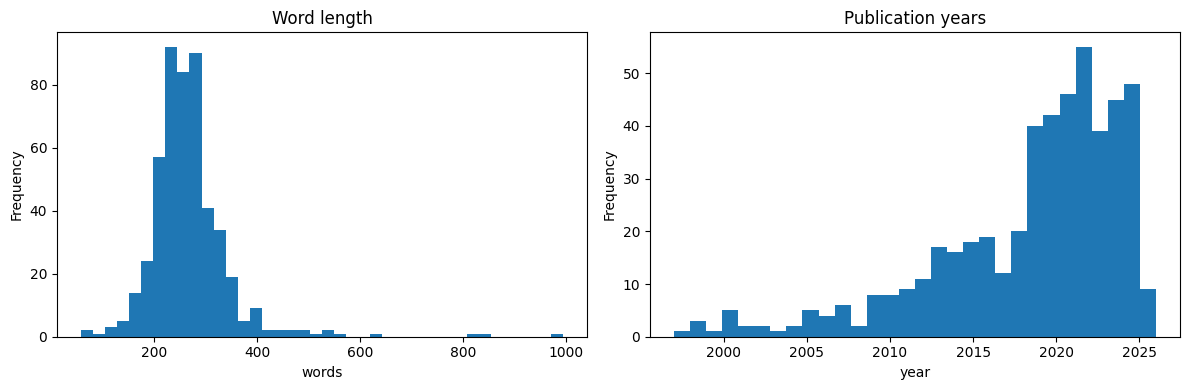

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["word_len"].plot(kind="hist", bins=40, ax=axes[0], title="Word length")
axes[0].set_xlabel("words")

df_year = df[df["year"].str.fullmatch(r"\d{4}")].copy()
if len(df_year):
    df_year["year"] = df_year["year"].astype(int)
    df_year["year"].plot(kind="hist", bins=min(30, df_year["year"].nunique()), ax=axes[1], title="Publication years")
    axes[1].set_xlabel("year")

plt.tight_layout()
plt.show()


In [8]:
text_for_kw = df["title"].fillna("") + " " + df["abstract"].fillna("")

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=max(2, int(0.01 * max(len(df), 1))),
    max_features=2000,
)

X = vectorizer.fit_transform(text_for_kw)
term_freq = np.asarray(X.sum(axis=0)).ravel()
terms = np.array(vectorizer.get_feature_names_out())

top_idx = np.argsort(term_freq)[::-1][:25]
keywords_df = pd.DataFrame({"term": terms[top_idx], "freq": term_freq[top_idx]})
keywords_df.head(20)


,term,freq
0,supplementation,1822
1,analysis,1384
2,trials,1306
3,meta,1222
4,vitamin,1180
5,95,1114
6,meta analysis,1080
7,review,996
8,ci,967
9,systematic,953


**Вывод по корпусу:**

- Корпус релевантен теме supplements и содержит клинические абстракты.
- Есть выраженные медицинские термы, что полезно для hybrid retrieval.
- Формулировки вопросов часто отличаются от заголовков, поэтому semsearch + rerank уместны.


## 3. Golden set через внешнюю LLM (Gemini)

В этой версии golden set генерируется внешней моделью `gemini-3-pro-preview`.

Процесс:
1. Сохраняем корпус PubMed в CSV (`./data/pubmed_supplements_corpus.csv`) и отдельный LLM-friendly CSV.
2. Формируем промпт с требованиями к разнообразию вопросов и формату JSON-ответа.
3. Отправляем CSV + промпт в Gemini (внешне).
4. Вставляем/сохраняем ответ Gemini в `./data/golden_from_gemini.json`.
5. Парсим JSON, валидируем поля, сохраняем `golden_supplements.parquet` (и CSV-копию).

Ниже все шаги документированы и готовы для использования.


### Обоснование golden set: покрытие и размер

- Golden set формируется внешней LLM (`gemini-3-pro-preview`) по реальным документам корпуса, с жёстким требованием не выдумывать PMID/URL.
- Размер выбран как `40` вопросов: это баланс между статистической устойчивостью метрик и временем полного прогона (retrieval + judge).
- В промпт заложено лексическое разнообразие: формальные/разговорные/короткие/длинные запросы и запросы с ошибками.
- Такое покрытие соответствует пользовательским сценариям retrieval и снижает риск переоценки системы на слишком «чистых» вопросах.


In [9]:
# Подготовка LLM-friendly источника для генерации golden set
GOLD_SOURCE_COLS = ["pmid", "title", "abstract", "journal", "year", "url"]
gold_source_df = df[GOLD_SOURCE_COLS].copy()

# Ограничиваем длину абстракта, чтобы уместить больше примеров в контекст внешней LLM
gold_source_df["abstract_for_llm"] = gold_source_df["abstract"].fillna("").str.slice(0, 1800)

llm_source_path = os.path.join(DATA_DIR, "pubmed_supplements_for_golden.csv")
gold_source_df[["pmid", "title", "abstract_for_llm", "journal", "year", "url"]].to_csv(llm_source_path, index=False)

print("Saved LLM source:", llm_source_path)
print("Rows for LLM generation:", len(gold_source_df))
gold_source_df.head(3)


Saved LLM source: ./data/pubmed_supplements_for_golden.csv
Rows for LLM generation: 496


,pmid,title,abstract,journal,year,url,abstract_for_llm
0,36017529,Does Ashwagandha supplementation have a beneficial effect on the management of anxiety and stress? A systematic review and meta-analysis...,"Clinical trial studies revealed conflicting results on the effect of Ashwagandha extract on anxiety and stress. Therefore, we aimed to e...",Phytotherapy research : PTR,2022,https://pubmed.ncbi.nlm.nih.gov/36017529/,"Clinical trial studies revealed conflicting results on the effect of Ashwagandha extract on anxiety and stress. Therefore, we aimed to e..."
1,35984306,Effects of creatine supplementation on memory in healthy individuals: a systematic review and meta-analysis of randomized controlled tri...,"CONTEXT: From an energy perspective, the brain is very metabolically demanding. It is well documented that creatine plays a key role in ...",Nutrition reviews,2023,https://pubmed.ncbi.nlm.nih.gov/35984306/,"CONTEXT: From an energy perspective, the brain is very metabolically demanding. It is well documented that creatine plays a key role in ..."
2,40324552,Effects of Collagen Supplements on Skin Aging: A Systematic Review and Meta-Analysis of Randomized Controlled Trials.,"BACKGROUND: Collagen supplements are promoted to help aging skin. However, no meta-analysis of randomized controlled trials (RCTs) has e...",The American journal of medicine,2025,https://pubmed.ncbi.nlm.nih.gov/40324552/,"BACKGROUND: Collagen supplements are promoted to help aging skin. However, no meta-analysis of randomized controlled trials (RCTs) has e..."


In [10]:
GEMINI_MODEL = "gemini-3-pro-preview"

GEMINI_GOLDEN_PROMPT = f"""
Ты генерируешь golden set для оценки retrieval в медицинском RAG по теме dietary supplements.

Источник данных: CSV-файл со столбцами:
- pmid
- title
- abstract_for_llm
- journal
- year
- url

Задача:
1. Сгенерируй 40 вопросов пользователя по корпусу.
2. Обязательно обеспечь лексическое и лингвистическое разнообразие:
   - корректные научные формулировки;
   - разговорные вопросы;
   - короткие вопросы;
   - длинные уточняющие вопросы;
   - вопросы с опечатками/ошибками;
   - разные уровни детализации.
3. Для каждого вопроса выбери 1 наиболее релевантную запись из CSV и верни:
   - question
   - gold_pmid
   - gold_text (короткий релевантный фрагмент из abstract_for_llm, 200-800 символов)
   - gold_title
   - gold_url
4. Не выдумывай PMID/URL/фрагменты: используй только данные из CSV.
5. Верни ТОЛЬКО валидный JSON без markdown и пояснений.

Формат ответа (строго):
{{
  "items": [
    {{
      "question": "...",
      "gold_pmid": "...",
      "gold_text": "...",
      "gold_title": "...",
      "gold_url": "..."
    }}
  ]
}}
""".strip()

prompt_path = os.path.join(DATA_DIR, "gemini_golden_prompt.txt")
with open(prompt_path, "w", encoding="utf-8") as f:
    f.write(GEMINI_GOLDEN_PROMPT)

print("Model:", GEMINI_MODEL)
print("Saved prompt:", prompt_path)


Model: gemini-3-pro-preview
Saved prompt: ./data/gemini_golden_prompt.txt


In [11]:
from pathlib import Path

GEMINI_OUTPUT_PATH = os.path.join(DATA_DIR, "golden_from_gemini.json")


def extract_json_block(text: str) -> dict[str, Any] | list[dict[str, Any]]:
    text = text.strip()
    if not text:
        raise ValueError("Пустой ответ Gemini")

    try:
        return json.loads(text)
    except Exception:
        pass

    # fallback: вырезаем первый JSON-блок
    m = re.search(r"\{[\s\S]*\}", text)
    if m:
        return json.loads(m.group(0))

    raise ValueError("Не удалось распарсить JSON из ответа Gemini")


if os.path.exists(GEMINI_OUTPUT_PATH):
    raw_gemini = Path(GEMINI_OUTPUT_PATH).read_text(encoding="utf-8")
    print("Loaded Gemini output from file:", GEMINI_OUTPUT_PATH)
else:
    raise FileNotFoundError("Не найден golden set от Gemini. Сохрани JSON в ./data/golden_from_gemini.json")

parsed = extract_json_block(raw_gemini)
if isinstance(parsed, dict):
    items = parsed.get("items", [])
elif isinstance(parsed, list):
    items = parsed
else:
    raise ValueError("Неподдерживаемый формат JSON от Gemini")

if not items:
    raise ValueError("В JSON нет элементов golden set (items пуст)")

golden_df = pd.DataFrame(items)
print("Raw golden rows from Gemini:", len(golden_df))
golden_df.head(5)


Loaded Gemini output from file: ./data/golden_from_gemini.json
Raw golden rows from Gemini: 40


,question,gold_pmid,gold_text,gold_title,gold_url
0,Does taking ashwagandha actually help with stress?,36017529,"We found that Ashwagandha supplementation significantly reduced anxiety (SMD: -1.55, 95% CI: -2.37, -0.74; p = .005; I(2) = 93.8%) and ...",Does Ashwagandha supplementation have a beneficial effect on the management of anxiety and stress? A systematic review and meta-analysis...,https://pubmed.ncbi.nlm.nih.gov/36017529/
1,effect of creatine monohydrate on memory in elderly,35984306,"Overall, creatine supplementation improved measures of memory compared with placebo (standard mean difference [SMD] = 0.29, 95%CI, 0.04-...",Effects of creatine supplementation on memory in healthy individuals: a systematic review and meta-analysis of randomized controlled tri...,https://pubmed.ncbi.nlm.nih.gov/35984306/
2,"I've heard collagen helps wrinkles, but does the funding source of the study matter?",40324552,"In a meta-analysis of all 23 RCTs, collagen supplements significantly improved skin hydration, elasticity, and wrinkles. However, in the...",Effects of Collagen Supplements on Skin Aging: A Systematic Review and Meta-Analysis of Randomized Controlled Trials.,https://pubmed.ncbi.nlm.nih.gov/40324552/
3,Is Vit B12 efffective for depression if I don't have a deficiency?,33809274,"Regarding cognitive function outcomes, we found no evidence for an effect of B12 alone or B complex supplementation on any subdomain of ...","Effects of Vitamin B12 Supplementation on Cognitive Function, Depressive Symptoms, and Fatigue: A Systematic Review, Meta-Analysis, and ...",https://pubmed.ncbi.nlm.nih.gov/33809274/
4,What supplements work best for dogs with arthritis? Is glucosamine good?,36142319,"Fifty-seven articles were included, comprising 72 trials divided into nine different categories of natural health compound. The efficacy...",A 2022 Systematic Review and Meta-Analysis of Enriched Therapeutic Diets and Nutraceuticals in Canine and Feline Osteoarthritis.,https://pubmed.ncbi.nlm.nih.gov/36142319/


In [12]:
# Нормализация и валидация golden set
rename_map = {
    "pmid": "gold_pmid",
    "title": "gold_title",
    "url": "gold_url",
    "text": "gold_text",
}
golden_df = golden_df.rename(columns={k: v for k, v in rename_map.items() if k in golden_df.columns})

required_cols = ["question", "gold_pmid", "gold_text", "gold_title", "gold_url"]
missing_cols = [c for c in required_cols if c not in golden_df.columns]
if missing_cols:
    raise ValueError(f"В ответе Gemini отсутствуют обязательные колонки: {missing_cols}")

golden_df = golden_df[required_cols].copy()
golden_df["question"] = golden_df["question"].astype(str).str.strip()
golden_df["gold_pmid"] = golden_df["gold_pmid"].astype(str).str.extract(r"(\d+)", expand=False).fillna("")
golden_df["gold_text"] = golden_df["gold_text"].astype(str).str.strip()
golden_df["gold_title"] = golden_df["gold_title"].astype(str).str.strip()
golden_df["gold_url"] = golden_df["gold_url"].astype(str).str.strip()

# если URL пустой, восстанавливаем из PMID
mask_empty_url = golden_df["gold_url"].eq("") & golden_df["gold_pmid"].ne("")
golden_df.loc[mask_empty_url, "gold_url"] = (
    "https://pubmed.ncbi.nlm.nih.gov/" + golden_df.loc[mask_empty_url, "gold_pmid"] + "/"
)

golden_df = golden_df[(golden_df["question"] != "") & (golden_df["gold_pmid"] != "") & (golden_df["gold_text"] != "")]
golden_df = golden_df.drop_duplicates(subset=["question", "gold_pmid"]).reset_index(drop=True)

q_lengths = golden_df["question"].str.split().str.len()
print("Golden size after validation:", len(golden_df))
print("Unique questions:", golden_df["question"].nunique())
print("Question length stats:")
print(q_lengths.describe())

print("\nSample questions:")
for q in golden_df["question"].sample(min(8, len(golden_df)), random_state=SEED):
    print("-", q)

gold_path = os.path.join(DATA_DIR, "golden_supplements.parquet")
golden_df.to_parquet(gold_path, index=False)
print("\nSaved:", gold_path)

gold_csv_path = os.path.join(DATA_DIR, "golden_supplements.csv")
golden_df.to_csv(gold_csv_path, index=False)
print("Saved:", gold_csv_path)


Golden size after validation: 40
Unique questions: 40
Question length stats:
count    40.000000
mean      9.525000
std       2.428332
min       5.000000
25%       8.000000
50%       9.000000
75%      11.250000
max      14.000000
Name: question, dtype: float64

Sample questions:
- Review of multivitamins for preventing heart disease and stroke.
- Are there any over the counter supplements that actully work for ED?
- Do B vitamins help with stress in healthy people?
- Is HMB effective for preventing muscle wasting in clinical conditions?
- What supplements work best for dogs with arthritis? Is glucosamine good?
- skin supplements for kids with eczema but no food allergies
- Is it better to take vitamin D daily or weekly to fix a deficiency?
- omega 3 for alzheimers cognitive function

Saved: ./data/golden_supplements.parquet
Saved: ./data/golden_supplements.csv


### Перевод:

#### Примеры вопросов:

* Обзор мультивитаминов для профилактики сердечно-сосудистых заболеваний и инсульта.
* Существуют ли безрецептурные добавки, которые действительно помогают при эректильной дисфункции?
* Помогают ли витамины группы B справиться со стрессом здоровым людям?
* Эффективен ли HMB для предотвращения потери мышечной массы при клинических состояниях?
* Какие добавки лучше всего подходят для собак с артритом? Полезен ли глюкозамин?
* Добавки для кожи для детей с экземой, но без пищевой аллергии.
* Как лучше принимать витамин D для устранения дефицита: ежедневно или раз в неделю?
* Омега-3 для улучшения когнитивных функций при болезни Альцгеймера.

## 4. Ретриверы и метрики

Hit определяется как наличие `gold_pmid` в top-k retrieved chunks.
Метрики: `P@k`, `MRR`, средняя latency на вопрос.


### Комментарий к методике оценки retrieval

- Критерий попадания (`hit`): в top-k должен присутствовать `gold_pmid`.
- Это более строгий критерий, чем строковое сравнение текста, и он лучше подходит для научного корпуса, где возможны перефразировки.
- Используются метрики:
  - `P@k` как вероятность найти релевантный источник в первых `k` документах;
  - `MRR` как качество ранжирования (насколько рано найден правильный PMID);
  - `avg_latency_sec` как инженерная стоимость метода.


In [13]:
base_docs = []
for row in df.itertuples(index=False):
    text = f"Title: {row.title}\n\nAbstract: {row.abstract}"
    base_docs.append(
        Document(
            page_content=text,
            metadata={
                "pmid": str(row.pmid),
                "title": row.title,
                "year": row.year,
                "url": row.url,
            },
        )
    )

splitter = RecursiveCharacterTextSplitter(
    chunk_size=900,
    chunk_overlap=120,
    separators=["\n\n", "\n", ". ", " ", ""],
)

doc_chunks = splitter.split_documents(base_docs)
for i, d in enumerate(doc_chunks):
    d.metadata["chunk_id"] = f"{d.metadata.get('pmid', 'na')}_{i}"

print("Base docs:", len(base_docs))
print("Chunks:", len(doc_chunks))


Base docs: 496
Chunks: 1793


### Обоснование выбора ретриверов

- `Dense` — основной семантический ретривер для перефразированных и «шумных» запросов.
- `BM25` — лексический baseline: дешёвый и полезный контроль на точные термы.
- `Hybrid` — попытка объединить сильные стороны lexical + semantic поиска.
- `Query expansion` — проверка устойчивости к вариативным формулировкам.

Такой набор покрывает базовые семейства retrieval-методов и позволяет сравнить trade-off качество/скорость.


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},
)

vectorstore = QdrantVectorStore.from_documents(
    documents=doc_chunks,
    embedding=embeddings,
    location=":memory:",
    collection_name="pubmed_supplements_chunks",
)

K_MAX = 10
dense_retriever = vectorstore.as_retriever(search_kwargs={"k": K_MAX})

bm25_retriever = BM25Retriever.from_documents(doc_chunks)
bm25_retriever.k = K_MAX


def _doc_key(doc: Document) -> str:
    return str(doc.metadata.get("chunk_id") or f"{doc.metadata.get('pmid', '')}:{hash(doc.page_content)}")


def hybrid_retrieve(
    query: str, k: int = K_MAX, dense_weight: float = 0.65, bm25_weight: float = 0.35
) -> list[Document]:
    dense_docs = dense_retriever.invoke(query)[:k]
    bm25_docs = bm25_retriever.invoke(query)[:k]

    ranked: dict[str, dict[str, object]] = {}

    # Reciprocal rank fusion: higher rank -> larger contribution
    for rank, d in enumerate(dense_docs, start=1):
        key = _doc_key(d)
        score = dense_weight / (rank + 60)
        if key not in ranked:
            ranked[key] = {"score": 0.0, "doc": d}
        ranked[key]["score"] = float(ranked[key]["score"]) + score

    for rank, d in enumerate(bm25_docs, start=1):
        key = _doc_key(d)
        score = bm25_weight / (rank + 60)
        if key not in ranked:
            ranked[key] = {"score": 0.0, "doc": d}
        ranked[key]["score"] = float(ranked[key]["score"]) + score

    merged = sorted(ranked.values(), key=lambda x: x["score"], reverse=True)
    return [item["doc"] for item in merged[:k]]


Device: cuda


In [15]:
EXPANSION_RULES = {
    "supplement": ["dietary supplement", "nutraceutical", "supplementation"],
    "vitamin": ["micronutrient", "vitamin supplementation"],
    "omega-3": ["fish oil", "n-3 fatty acids", "EPA DHA"],
    "effect": ["efficacy", "clinical outcome", "benefit"],
    "safety": ["adverse effects", "tolerability", "risk"],
}


def expand_query(query: str, max_expansions: int = 4) -> list[str]:
    expansions = [query]
    q_low = query.lower()

    for key, vals in EXPANSION_RULES.items():
        if key in q_low:
            for val in vals:
                expansions.append(re.sub(key, val, query, flags=re.IGNORECASE))

    if len(expansions) == 1:
        expansions.extend(
            [
                f"{query} clinical trial",
                f"{query} systematic review",
                f"{query} meta-analysis",
            ]
        )

    uniq = []
    seen = set()
    for x in expansions:
        x = x.strip()
        if x and x not in seen:
            uniq.append(x)
            seen.add(x)
    return uniq[:max_expansions]


def retrieve_with_expansion(query: str, k: int = K_MAX) -> list[Document]:
    merged = []
    seen_ids = set()
    for sq in expand_query(query, max_expansions=4):
        docs = dense_retriever.invoke(sq)
        for d in docs:
            cid = d.metadata.get("chunk_id")
            if cid not in seen_ids:
                seen_ids.add(cid)
                merged.append(d)
    return merged[:k]


In [16]:
@dataclass
class EvalResult:
    name: str
    p_at_k: dict[int, float]
    mrr: float
    avg_latency_sec: float
    details: pd.DataFrame


def evaluate_retriever(golden_df: pd.DataFrame, retrieve_fn, k_values: tuple[int, ...] = (1, 3, 5, 10)) -> EvalResult:
    hits_at_k = {k: 0 for k in k_values}
    reciprocal_ranks = []
    latencies = []
    rows = []

    for row in golden_df.itertuples(index=False):
        q = row.question
        gold_pmid = str(row.gold_pmid)

        t0 = time.perf_counter()
        docs = retrieve_fn(q)[: max(k_values)]
        dt = time.perf_counter() - t0
        latencies.append(dt)

        rank = None
        pmids = []
        for i, d in enumerate(docs, start=1):
            pmid = str(d.metadata.get("pmid", ""))
            pmids.append(pmid)
            if pmid == gold_pmid and rank is None:
                rank = i

        reciprocal_ranks.append(1 / rank if rank else 0)
        for k in k_values:
            if rank and rank <= k:
                hits_at_k[k] += 1

        rows.append(
            {
                "question": q,
                "gold_pmid": gold_pmid,
                "retrieved_pmids": pmids,
                "rank": rank,
                "latency_sec": dt,
            }
        )

    p_at_k = {k: hits_at_k[k] / len(golden_df) for k in k_values}
    mrr = float(np.mean(reciprocal_ranks)) if reciprocal_ranks else 0.0
    avg_latency = float(np.mean(latencies)) if latencies else 0.0

    return EvalResult("", p_at_k, mrr, avg_latency, pd.DataFrame(rows))


def dense_fn(q: str) -> list[Document]:
    return dense_retriever.invoke(q)


def bm25_fn(q: str) -> list[Document]:
    return bm25_retriever.invoke(q)


def hybrid_fn(q: str) -> list[Document]:
    return hybrid_retrieve(q, k=K_MAX)


def expanded_dense_fn(q: str) -> list[Document]:
    return retrieve_with_expansion(q, k=K_MAX)


In [17]:
results = {}
for name, fn in [
    ("dense", dense_fn),
    ("bm25", bm25_fn),
    ("hybrid", hybrid_fn),
    ("dense+query_expansion", expanded_dense_fn),
]:
    r = evaluate_retriever(golden_df, fn, k_values=(1, 3, 5, 10))
    r.name = name
    results[name] = r

comparison_df = (
    pd.DataFrame(
        [
            {
                "retriever": name,
                "P@1": r.p_at_k[1],
                "P@3": r.p_at_k[3],
                "P@5": r.p_at_k[5],
                "P@10": r.p_at_k[10],
                "MRR": r.mrr,
                "avg_latency_sec": r.avg_latency_sec,
            }
            for name, r in results.items()
        ]
    )
    .sort_values("MRR", ascending=False)
    .reset_index(drop=True)
)

comparison_df


,retriever,P@1,P@3,P@5,P@10,MRR,avg_latency_sec
0,dense,0.875,0.975,1.00,1.0,0.927083,0.023428
1,dense+query_expansion,0.875,0.975,1.00,1.0,0.927083,0.081979
2,hybrid,0.775,0.900,1.00,1.0,0.855833,0.023134
3,bm25,0.375,0.575,0.65,0.7,0.495030,0.003310


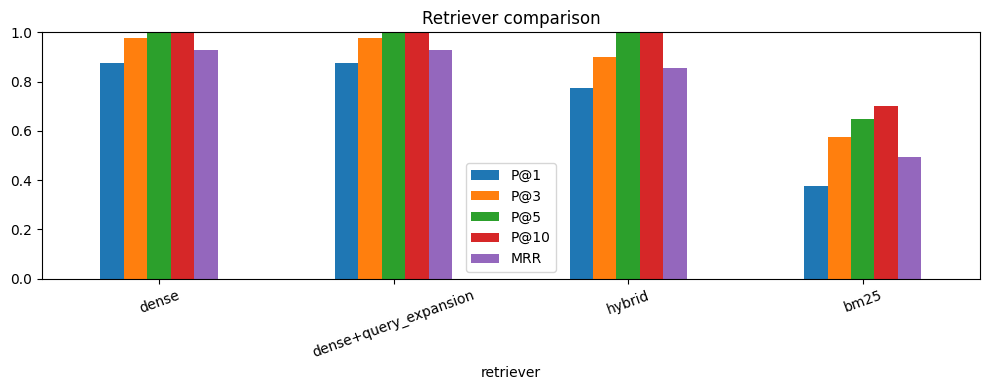

In [18]:
ax = comparison_df.set_index("retriever")[["P@1", "P@3", "P@5", "P@10", "MRR"]].plot(
    kind="bar", figsize=(10, 4), rot=20
)
ax.set_ylim(0, 1)
ax.set_title("Retriever comparison")
plt.tight_layout()
plt.show()


In [19]:
# Человекочитаемый итог по retrieval
retr_sorted = comparison_df.sort_values(["MRR", "P@1", "avg_latency_sec"], ascending=[False, False, True]).reset_index(
    drop=True
)
print("Итог по retrievers (лучше -> хуже):")
for _, row in retr_sorted.iterrows():
    print(
        f"- {row['retriever']:22s} | P@1={row['P@1']:.3f} | MRR={row['MRR']:.3f} | latency={row['avg_latency_sec']:.4f}s"
    )
print(f"\nЛучший retriever в этом прогоне: {retr_sorted.iloc[0]['retriever']}")


Итог по retrievers (лучше -> хуже):
- dense                  | P@1=0.875 | MRR=0.927 | latency=0.0234s
- dense+query_expansion  | P@1=0.875 | MRR=0.927 | latency=0.0820s
- hybrid                 | P@1=0.775 | MRR=0.856 | latency=0.0231s
- bm25                   | P@1=0.375 | MRR=0.495 | latency=0.0033s

Лучший retriever в этом прогоне: dense


### Интерпретация результата retrieval

По текущему golden set лучший результат дал **dense retriever без дополнительных модификаций** (`P@1` и `MRR` максимальны среди сравниваемых вариантов).

Почему это могло произойти:
- Вопросы из golden set семантически близки к формулировкам в абстрактах, и dense-эмбеддинги хорошо ловят эту близость.
- `BM25` проигрывает на перефразированных и разговорных запросах, где нет точного лексического совпадения.
- `Hybrid` и `query expansion` не дали прироста в этой выборке: вероятно, добавили шум в ранжирование и не улучшили top-1.
- Вывод относится именно к **данному корпусу и текущей версии golden set**; при смене распределения вопросов лидер может измениться.


## 5. LLM-оценка релевантности и latency

Сравниваем dense baseline против dense + LLM-rerank **на всём golden set**.

Ниже используется последовательный режим загрузки моделей (по очереди), чтобы уложиться в VRAM 8GB.


### Обоснование надежности LLM-as-a-judge

- Судья работает в детерминированном режиме (`do_sample=False`) и обязан возвращать строгий JSON.
- Реализован fallback-парсинг ответа, чтобы не падать на форматных артефактах модели.
- Для контроля качества добавлены cherry-pick проверки: лучший/худший/hallucination-кейсы с чтением глазами.
- Ограничение: single-judge может быть смещён; для финальной валидации желательно ручное согласование на части примеров.


In [20]:
# Загружаем judge-модель (по очереди, освобождая VRAM)
unload_pipelines("gen_pipe", "judge_pipe")

JUDGE_MODEL = HEAVY_MODEL_NAME
judge_pipe, JUDGE_MODEL_LOADED = build_textgen_pipeline(JUDGE_MODEL, use_4bit=USE_4BIT)


Loading checkpoint shards: 100%|██████████| 4/4 [00:46<00:00, 11.63s/it]


Loaded model: Qwen/Qwen2.5-7B-Instruct | 4bit=True


In [21]:
def extract_json_object(text: str) -> dict[str, Any]:
    text = text.strip()
    if not text:
        return {"score": 0.0, "is_relevant": False}

    # 1) Пробуем распарсить весь ответ как JSON
    try:
        obj = json.loads(text)
    except Exception:
        obj = None

    # 2) Если не вышло, достаём первый JSON-объект из текста
    if obj is None:
        m = re.search(r"\{[\s\S]*?\}", text)
        if m:
            try:
                obj = json.loads(m.group(0))
            except Exception:
                obj = None

    # 3) Нормализация: всегда возвращаем dict
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, list) and obj and isinstance(obj[0], dict):
        return obj[0]

    return {"score": 0.0, "is_relevant": False}


def _extract_generated_content(output_item: Any) -> str:
    # pipeline может вернуть dict, list[dict], list[str], str
    if isinstance(output_item, list):
        if not output_item:
            return ""
        output_item = output_item[0]

    if isinstance(output_item, str):
        return output_item

    if isinstance(output_item, dict):
        gen_text = output_item.get("generated_text", "")
        if isinstance(gen_text, list) and gen_text:
            last = gen_text[-1]
            if isinstance(last, dict):
                return str(last.get("content", ""))
            return str(last)
        return str(gen_text)

    return str(output_item)


def _extract_score(parsed: Any) -> float:
    if isinstance(parsed, dict):
        raw = parsed.get("score", 0.0)
    else:
        raw = 0.0

    try:
        score = float(raw)
    except Exception:
        score = 0.0

    return max(0.0, min(1.0, score))


def llm_relevance_score(question: str, candidate_text: str, max_new_tokens: int = 96) -> float:
    system = (
        "You are a strict relevance judge for biomedical retrieval. "
        'Return only JSON: {"score": float 0..1, "is_relevant": boolean}.'
    )
    user = f"Question:\n{question}\n\nCandidate context:\n{candidate_text[:1800]}"

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]

    out = judge_pipe(messages, max_new_tokens=max_new_tokens, do_sample=False)
    raw = _extract_generated_content(out[0])
    parsed = extract_json_object(raw)
    return _extract_score(parsed)


def llm_rerank(question: str, docs: list[Document], top_k: int = K_MAX, batch_size: int = 8) -> list[Document]:
    candidates = docs[:top_k]
    if not candidates:
        return []

    system = (
        "You are a strict relevance judge for biomedical retrieval. "
        'Return only JSON: {"score": float 0..1, "is_relevant": boolean}.'
    )

    messages_batch = [
        [
            {"role": "system", "content": system},
            {"role": "user", "content": f"Question:\n{question}\n\nCandidate context:\n{d.page_content[:1800]}"},
        ]
        for d in candidates
    ]

    outputs = judge_pipe(messages_batch, max_new_tokens=96, do_sample=False, batch_size=batch_size)

    scored = []
    for d, out_item in zip(candidates, outputs):
        raw = _extract_generated_content(out_item)
        parsed = extract_json_object(raw)
        score = _extract_score(parsed)
        scored.append((score, d))

    scored.sort(key=lambda x: x[0], reverse=True)
    return [d for _, d in scored]


def dense_plus_llm_rerank_fn(q: str) -> list[Document]:
    base = dense_retriever.invoke(q)
    return llm_rerank(q, base, top_k=min(K_MAX, len(base)))


In [22]:
# Оцениваем на всём golden set
golden_subset = golden_df.copy().reset_index(drop=True)

print("Questions for LLM-rerank eval:", len(golden_subset))

dense_subset_eval = evaluate_retriever(golden_subset, dense_fn, k_values=(1, 3, 5, 10))
llm_rerank_eval = evaluate_retriever(golden_subset, dense_plus_llm_rerank_fn, k_values=(1, 3, 5, 10))

llm_compare = pd.DataFrame(
    [
        {
            "setup": "dense_baseline",
            "P@1": dense_subset_eval.p_at_k[1],
            "P@3": dense_subset_eval.p_at_k[3],
            "P@5": dense_subset_eval.p_at_k[5],
            "P@10": dense_subset_eval.p_at_k[10],
            "MRR": dense_subset_eval.mrr,
            "avg_latency_sec": dense_subset_eval.avg_latency_sec,
        },
        {
            "setup": "dense + llm_rerank",
            "P@1": llm_rerank_eval.p_at_k[1],
            "P@3": llm_rerank_eval.p_at_k[3],
            "P@5": llm_rerank_eval.p_at_k[5],
            "P@10": llm_rerank_eval.p_at_k[10],
            "MRR": llm_rerank_eval.mrr,
            "avg_latency_sec": llm_rerank_eval.avg_latency_sec,
        },
    ]
)

llm_compare


Questions for LLM-rerank eval: 40


,setup,P@1,P@3,P@5,P@10,MRR,avg_latency_sec
0,dense_baseline,0.875,0.975,1.000,1.0,0.927083,0.024106
1,dense + llm_rerank,0.825,0.950,0.975,1.0,0.896071,7.381330


In [23]:
# Человекочитаемый итог по LLM-rerank
base = llm_compare[llm_compare["setup"] == "dense_baseline"].iloc[0]
rerank = llm_compare[llm_compare["setup"] == "dense + llm_rerank"].iloc[0]

print("Dense baseline:")
print(f"- P@1={base['P@1']:.3f}, MRR={base['MRR']:.3f}, latency={base['avg_latency_sec']:.3f}s")
print("Dense + LLM-rerank:")
print(f"- P@1={rerank['P@1']:.3f}, MRR={rerank['MRR']:.3f}, latency={rerank['avg_latency_sec']:.3f}s")

print("\nДельта (rerank - baseline):")
print(f"- ΔP@1={rerank['P@1'] - base['P@1']:+.3f}")
print(f"- ΔMRR={rerank['MRR'] - base['MRR']:+.3f}")
print(f"- Δlatency={rerank['avg_latency_sec'] - base['avg_latency_sec']:+.3f}s")


Dense baseline:
- P@1=0.875, MRR=0.927, latency=0.024s
Dense + LLM-rerank:
- P@1=0.825, MRR=0.896, latency=7.381s

Дельта (rerank - baseline):
- ΔP@1=-0.050
- ΔMRR=-0.031
- Δlatency=+7.357s


In [24]:
# Cherry-pick: как LLM-rerank ведёт себя на отдельных вопросах
base_df = dense_subset_eval.details.rename(
    columns={
        "rank": "rank_dense",
        "retrieved_pmids": "pmids_dense",
        "latency_sec": "lat_dense",
    }
)[["question", "gold_pmid", "rank_dense", "pmids_dense", "lat_dense"]]

rerank_df = llm_rerank_eval.details.rename(
    columns={
        "rank": "rank_rerank",
        "retrieved_pmids": "pmids_rerank",
        "latency_sec": "lat_rerank",
    }
)[["question", "gold_pmid", "rank_rerank", "pmids_rerank", "lat_rerank"]]

cmp = base_df.merge(rerank_df, on=["question", "gold_pmid"], how="inner")
cmp["rank_dense_num"] = pd.to_numeric(cmp["rank_dense"], errors="coerce")
cmp["rank_rerank_num"] = pd.to_numeric(cmp["rank_rerank"], errors="coerce")
cmp["delta_rank"] = cmp["rank_rerank_num"] - cmp["rank_dense_num"]

picked = []
# 1) кейс ухудшения
worse = cmp[(cmp["rank_dense_num"].notna()) & (cmp["rank_rerank_num"].notna()) & (cmp["delta_rank"] > 0)].sort_values(
    "delta_rank", ascending=False
)
if len(worse):
    picked.append(("Ухудшение", worse.iloc[0]))

# 2) кейс улучшения
better = cmp[(cmp["rank_dense_num"].notna()) & (cmp["rank_rerank_num"].notna()) & (cmp["delta_rank"] < 0)].sort_values(
    "delta_rank", ascending=True
)
if len(better):
    picked.append(("Улучшение", better.iloc[0]))

# 3) кейс стабильности/около нуля
stable = cmp[(cmp["rank_dense_num"].notna()) & (cmp["rank_rerank_num"].notna()) & (cmp["delta_rank"] == 0)]
if len(stable):
    picked.append(("Без изменений", stable.iloc[0]))

if not picked and len(cmp):
    picked.append(("Пример", cmp.iloc[0]))

for i, (label, row) in enumerate(picked[:3], start=1):
    print(f"\n[{i}] {label}")
    print(f"Вопрос: {row['question']}")
    print(f"Gold PMID: {row['gold_pmid']}")
    print(f"Dense rank -> {row['rank_dense']} | top5 pmids: {row['pmids_dense'][:5]}")
    print(f"Rerank rank -> {row['rank_rerank']} | top5 pmids: {row['pmids_rerank'][:5]}")
    print(f"Latency: dense={row['lat_dense']:.4f}s, rerank={row['lat_rerank']:.4f}s")



[1] Ухудшение
Вопрос: meta-analysis of vitamin supplements for cognition in healthy older adults
Gold PMID: 30556597
Dense rank -> 4 | top5 pmids: ['40966571', '35473808', '30949983', '30556597', '34432056']
Rerank rank -> 7 | top5 pmids: ['35473808', '40966571', '40966571', '39064642', '35473808']
Latency: dense=0.0206s, rerank=5.2123s

[2] Улучшение
Вопрос: does vit d help with atopic dermatitis severity?
Gold PMID: 39683522
Dense rank -> 3 | top5 pmids: ['27061361', '27061361', '39683522', '39683522', '39683522']
Rerank rank -> 2 | top5 pmids: ['27061361', '39683522', '39683522', '27061361', '39683522']
Latency: dense=0.0228s, rerank=6.0289s

[3] Без изменений
Вопрос: effect of creatine monohydrate on memory in elderly
Gold PMID: 35984306
Dense rank -> 1 | top5 pmids: ['35984306', '35984306', '35984306', '35984306', '36877404']
Rerank rank -> 1 | top5 pmids: ['35984306', '35984306', '35984306', '35984306', '36877404']
Latency: dense=0.0330s, rerank=5.8242s


## 6. Генерация RAG-ответов и LLM-as-a-judge

### Комментарий к разметке ответов

- Метод разметки: `LLM-as-a-judge` по четырём полям (`faithfulness`, `completeness`, `overall`, `hallucination`).
- Плюс метода: масштабируется на полный golden set и даёт структурированные метрики.
- Риск: judge может быть строгим/мягким в зависимости от промпта.
- Поэтому в отчёте результаты judge интерпретируются вместе с ручными cherry-pick примерами, а не только по средним числам.


In [25]:
# Перед генерацией выгружаем judge и грузим генеративную модель
unload_pipelines("judge_pipe", "gen_pipe")

GEN_MODEL = HEAVY_MODEL_NAME
gen_pipe, GEN_MODEL_LOADED = build_textgen_pipeline(GEN_MODEL, use_4bit=USE_4BIT)


def format_context(docs: list[Document], max_docs: int = 5, max_chars_each: int = 1200) -> str:
    lines = []
    for i, d in enumerate(docs[:max_docs], start=1):
        pmid = d.metadata.get("pmid", "")
        url = d.metadata.get("url", "")
        title = d.metadata.get("title", "")
        chunk = d.page_content[:max_chars_each]
        lines.append(f"[{i}] PMID={pmid} | {title}\n{chunk}\nSource: {url}")
    return "\n\n".join(lines)


def generate_rag_answer(question: str, retrieve_fn=hybrid_fn, k: int = 5, max_new_tokens: int = 220):
    docs = retrieve_fn(question)[:k]
    context = format_context(docs, max_docs=k)

    system = (
        "You are a biomedical assistant. Use only provided context. "
        "If evidence is insufficient, say so. Always cite PMID."
    )
    user = f"Question:\n{question}\n\nContext:\n{context}\n\nReturn concise answer with citations like [PMID:12345678]."

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]

    out = gen_pipe(messages, max_new_tokens=max_new_tokens, do_sample=False)
    answer = out[0]["generated_text"][-1]["content"]
    return answer, docs


Loading checkpoint shards: 100%|██████████| 4/4 [00:09<00:00,  2.33s/it]


Loaded model: Qwen/Qwen2.5-7B-Instruct | 4bit=True


In [ ]:
def _safe_bool(value: Any, default: bool = False) -> bool:
    if isinstance(value, bool):
        return value
    if value is None:
        return default
    if isinstance(value, (int, float)):
        return bool(value)
    if isinstance(value, str):
        v = value.strip().lower()
        if v in {"true", "1", "yes", "y", "да"}:
            return True
        if v in {"false", "0", "no", "n", "нет"}:
            return False
        return default
    return default


def judge_generated_answer(question: str, answer: str, gold_text: str) -> dict[str, Any]:
    system = (
        "You are a strict evaluator of QA quality. "
        "Return JSON only with: faithfulness (0..1), completeness (0..1), "
        "hallucination (boolean), overall (0..1), comment (string)."
    )
    user = f"Question:\n{question}\n\nGenerated answer:\n{answer}\n\nReference evidence:\n{gold_text[:1600]}"

    messages = [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]

    out = judge_pipe(messages, max_new_tokens=180, do_sample=False)
    raw = _extract_generated_content(out[0])
    parsed = extract_json_block(raw)

    return {
        "faithfulness": float(parsed.get("faithfulness", 0.0)) if isinstance(parsed, dict) else 0.0,
        "completeness": float(parsed.get("completeness", 0.0)) if isinstance(parsed, dict) else 0.0,
        "hallucination": _safe_bool(
            parsed.get("hallucination", False) if isinstance(parsed, dict) else False,
            default=False,
        ),
        "overall": float(parsed.get("overall", 0.0)) if isinstance(parsed, dict) else 0.0,
        "comment": str(parsed.get("comment", "")) if isinstance(parsed, dict) else "",
    }


In [27]:
run_n = len(golden_df)

# Шаг 1. Генерация ответов (только gen_pipe)
gen_rows = []
for row in tqdm(golden_df.head(run_n).itertuples(index=False), total=run_n, desc="RAG generation"):
    answer, docs = generate_rag_answer(row.question, retrieve_fn=hybrid_fn, k=5)
    gen_rows.append(
        {
            "question": row.question,
            "gold_pmid": row.gold_pmid,
            "gold_text": row.gold_text,
            "answer": answer,
            "top_pmids": [d.metadata.get("pmid", "") for d in docs],
        }
    )

generated_answers_df = pd.DataFrame(gen_rows)
print("Generated answers:", len(generated_answers_df))
display(generated_answers_df.head(5))

# Шаг 2. Освобождаем VRAM и грузим judge-модель
unload_pipelines("gen_pipe", "judge_pipe")

JUDGE_MODEL = HEAVY_MODEL_NAME
judge_pipe, JUDGE_MODEL_LOADED = build_textgen_pipeline(JUDGE_MODEL, use_4bit=USE_4BIT)

# Шаг 3. Judge-оценка уже с отдельной моделью
eval_rows = []
for row in tqdm(generated_answers_df.itertuples(index=False), total=len(generated_answers_df), desc="Judge scoring"):
    judge = judge_generated_answer(row.question, row.answer, row.gold_text)
    eval_rows.append(
        {
            "question": row.question,
            "gold_pmid": row.gold_pmid,
            "gold_text": row.gold_text,
            "answer": row.answer,
            "top_pmids": row.top_pmids,
            "faithfulness": judge["faithfulness"],
            "completeness": judge["completeness"],
            "hallucination": judge["hallucination"],
            "overall": judge["overall"],
            "judge_comment": judge["comment"],
        }
    )

answers_eval_df = pd.DataFrame(eval_rows)
answers_eval_df.head(5)


RAG generation: 100%|██████████| 40/40 [05:57<00:00,  8.93s/it]

Generated answers: 40


,question,gold_pmid,gold_text,answer,top_pmids
0,Does taking ashwagandha actually help with stress?,36017529,"We found that Ashwagandha supplementation significantly reduced anxiety (SMD: -1.55, 95% CI: -2.37, -0.74; p = .005; I(2) = 93.8%) and ...",Taking ashwagandha appears to have a beneficial effect on reducing anxiety and stress levels. A systematic review and meta-analysis of r...,"[36017529, 36017529, 36017529, 32316411, 32316411]"
1,effect of creatine monohydrate on memory in elderly,35984306,"Overall, creatine supplementation improved measures of memory compared with placebo (standard mean difference [SMD] = 0.29, 95%CI, 0.04-...",The systematic review and meta-analysis by PMID:35984306 found that creatine supplementation significantly improved memory performance i...,"[35984306, 35984306, 35984306, 36877404, 36877404]"
2,"I've heard collagen helps wrinkles, but does the funding source of the study matter?",40324552,"In a meta-analysis of all 23 RCTs, collagen supplements significantly improved skin hydration, elasticity, and wrinkles. However, in the...",The funding source of the study can indeed influence the results. In the context of the study on collagen supplements for skin aging (PM...,"[40324552, 36142319, 40324552, 40324552, 39358652]"
3,Is Vit B12 efffective for depression if I don't have a deficiency?,33809274,"Regarding cognitive function outcomes, we found no evidence for an effect of B12 alone or B complex supplementation on any subdomain of ...","Based on the provided context, there is no strong evidence to support the use of Vitamin B12 for treating depression in individuals who ...","[33809274, 33809274, 33809274, 17461847, 28202095]"
4,What supplements work best for dogs with arthritis? Is glucosamine good?,36142319,"Fifty-seven articles were included, comprising 72 trials divided into nine different categories of natural health compound. The efficacy...","Based on the provided context, glucosamine supplements do not show a significant efficacy in managing pain in canine osteoarthritis. Acc...","[36142319, 36142319, 36142319, 39203777, 33396851]"


Loading checkpoint shards: 100%|██████████| 4/4 [00:09<00:00,  2.32s/it]


Loaded model: Qwen/Qwen2.5-7B-Instruct | 4bit=True


Judge scoring: 100%|██████████| 40/40 [03:51<00:00,  5.78s/it]


,question,gold_pmid,gold_text,answer,top_pmids,faithfulness,completeness,hallucination,overall,judge_comment
0,Does taking ashwagandha actually help with stress?,36017529,"We found that Ashwagandha supplementation significantly reduced anxiety (SMD: -1.55, 95% CI: -2.37, -0.74; p = .005; I(2) = 93.8%) and ...",Taking ashwagandha appears to have a beneficial effect on reducing anxiety and stress levels. A systematic review and meta-analysis of r...,"[36017529, 36017529, 36017529, 32316411, 32316411]",1.0,1.0,False,1.00,"The answer accurately reflects the provided reference evidence, including statistical data and the certainty of the evidence. It is comp..."
1,effect of creatine monohydrate on memory in elderly,35984306,"Overall, creatine supplementation improved measures of memory compared with placebo (standard mean difference [SMD] = 0.29, 95%CI, 0.04-...",The systematic review and meta-analysis by PMID:35984306 found that creatine supplementation significantly improved memory performance i...,"[35984306, 35984306, 35984306, 36877404, 36877404]",0.8,0.9,False,0.85,"The answer provides relevant information from a systematic review and meta-analysis, but it includes some unnecessary details and does n..."
2,"I've heard collagen helps wrinkles, but does the funding source of the study matter?",40324552,"In a meta-analysis of all 23 RCTs, collagen supplements significantly improved skin hydration, elasticity, and wrinkles. However, in the...",The funding source of the study can indeed influence the results. In the context of the study on collagen supplements for skin aging (PM...,"[40324552, 36142319, 40324552, 40324552, 39358652]",0.8,0.9,False,0.85,The answer provides relevant information about the impact of funding sources on study outcomes regarding collagen supplements. It includ...
3,Is Vit B12 efffective for depression if I don't have a deficiency?,33809274,"Regarding cognitive function outcomes, we found no evidence for an effect of B12 alone or B complex supplementation on any subdomain of ...","Based on the provided context, there is no strong evidence to support the use of Vitamin B12 for treating depression in individuals who ...","[33809274, 33809274, 33809274, 17461847, 28202095]",1.0,1.0,False,1.00,The answer accurately reflects the provided reference evidence and is comprehensive in addressing the question.
4,What supplements work best for dogs with arthritis? Is glucosamine good?,36142319,"Fifty-seven articles were included, comprising 72 trials divided into nine different categories of natural health compound. The efficacy...","Based on the provided context, glucosamine supplements do not show a significant efficacy in managing pain in canine osteoarthritis. Acc...","[36142319, 36142319, 36142319, 39203777, 33396851]",0.8,0.9,False,0.85,"The answer provides a detailed analysis based on the reference evidence, including specific supplements and their efficacy. It correctly..."


In [28]:
if len(answers_eval_df):
    summary_df = pd.DataFrame(
        [
            {
                "mean_faithfulness": answers_eval_df["faithfulness"].mean(),
                "mean_completeness": answers_eval_df["completeness"].mean(),
                "mean_overall": answers_eval_df["overall"].mean(),
                "hallucination_rate": answers_eval_df["hallucination"].mean(),
            }
        ]
    )
    display(summary_df)

answers_path = os.path.join(DATA_DIR, "answers_eval.parquet")
if len(answers_eval_df):
    answers_eval_df.to_parquet(answers_path, index=False)
    print("Saved:", answers_path)


,mean_faithfulness,mean_completeness,mean_overall,hallucination_rate
0,0.885,0.92625,0.9055,0.0


Saved: ./data/answers_eval.parquet


In [29]:
# Человекочитаемый итог по качеству ответов
if len(answers_eval_df):
    mean_f = answers_eval_df["faithfulness"].mean()
    mean_c = answers_eval_df["completeness"].mean()
    mean_o = answers_eval_df["overall"].mean()
    hall = answers_eval_df["hallucination"].mean()

    print("Качество ответов на golden set:")
    print(f"- Faithfulness: {mean_f:.3f}")
    print(f"- Completeness: {mean_c:.3f}")
    print(f"- Overall: {mean_o:.3f}")
    print(f"- Hallucination rate: {hall:.3f}")


Качество ответов на golden set:
- Faithfulness: 0.885
- Completeness: 0.926
- Overall: 0.905
- Hallucination rate: 0.000


In [30]:
# Cherry-pick: как LLM-судья оценивает ответы (2-3 примера)
if len(answers_eval_df):
    merged = answers_eval_df.copy()

    # Подтягиваем gold_text только если его нет
    if "gold_text" not in merged.columns:
        merged = merged.merge(
            golden_df[["question", "gold_text"]],
            on="question",
            how="left",
        )

    # Нормализуем имя колонки gold_text после merge
    if "gold_text" not in merged.columns:
        for cand in ["gold_text_y", "gold_text_x"]:
            if cand in merged.columns:
                merged["gold_text"] = merged[cand]
                break
    if "gold_text" not in merged.columns:
        merged["gold_text"] = ""

    chosen = []

    worst = merged.sort_values("overall", ascending=True)
    if len(worst):
        chosen.append(("Худший overall", worst.iloc[0]))

    best = merged.sort_values("overall", ascending=False)
    if len(best):
        chosen.append(("Лучший overall", best.iloc[0]))

    hall = merged[merged["hallucination"] == True]
    if len(hall):
        chosen.append(("Кейс с hallucination=True", hall.iloc[0]))

    uniq, seen = [], set()
    for label, row in chosen:
        q = row["question"]
        if q not in seen:
            seen.add(q)
            uniq.append((label, row))

    for i, (label, row) in enumerate(uniq[:3], start=1):
        top_pmids = row["top_pmids"] if isinstance(row["top_pmids"], list) else []
        gold_text = str(row.get("gold_text", ""))

        print(f"\n[{i}] {label}")
        print(f"Q: {row['question']}")
        print(f"Gold PMID: {row['gold_pmid']} | Retrieved top PMIDs: {top_pmids[:5]}")
        print(
            f"Judge scores -> faithfulness={row['faithfulness']:.3f}, "
            f"completeness={row['completeness']:.3f}, overall={row['overall']:.3f}, "
            f"hallucination={row['hallucination']}"
        )
        print(f"Judge comment: {row['judge_comment']}")
        print(f"Answer snippet: {str(row['answer'])[:500]}{'...' if len(str(row['answer'])) > 500 else ''}")
        print(f"Gold snippet: {gold_text[:350]}{'...' if len(gold_text) > 350 else ''}")


[1] Худший overall
Q: Results of the COSMOS trial regarding multivitamin effects on memory in older adults.
Gold PMID: 38244989 | Retrieved top PMIDs: ['38244989', '37035889', '37035889', '38244989', '30556597']
Judge scores -> faithfulness=0.800, completeness=0.600, overall=0.700, hallucination=False
Judge comment: The generated answer is mostly faithful to the reference evidence, mentioning both the lack of significant effects and the modest benefits found in some studies. However, it does not fully capture the details from the reference, such as the specific SD units and confidence intervals, which could provide more context. 
Answer snippet: The COSMOS trial did not find significant effects of multivitamin-mineral supplementation on cognitive function in older adults. The study used in-person, detailed neuropsychological assessments and found no differences in cognitive change between those taking multivitamins and those taking a placebo [PMID:38244989]. Additionally, the incidenc

## Перевод и ручная проверка:

### [1] Худший по общему баллу (Overall)

**Вопрос (Q):** Результаты исследования COSMOS относительно влияния мультивитаминов на память у пожилых людей.

**Золотой стандарт (Gold) PMID:** 38244989 | **Полученные топ-PMID:** ['38244989', '37035889', '37035889', '38244989', '30556597']

**Оценки судьи:**

* Достоверность (faithfulness) = 0.800
* Полнота (completeness) = 0.600
* Общий балл (overall) = 0.700
* Галлюцинации (hallucination) = False (Нет)

**Комментарий судьи:** Сгенерированный ответ в основном соответствует справочным доказательствам, упоминая как отсутствие значимых эффектов, так и скромную пользу, обнаруженную в некоторых исследованиях. Однако он не полностью отражает детали из первоисточника, такие как конкретные единицы стандартного отклонения (SD) и доверительные интервалы, которые могли бы дать больше контекста.

**Фрагмент ответа:** Исследование COSMOS не выявило значительного влияния приема мультивитаминно-минеральных комплексов на когнитивные функции у пожилых людей. В исследовании использовались очные подробные нейропсихологические тесты, которые не показали различий в изменении когнитивных способностей между теми, кто принимал мультивитамины, и теми, кто принимал плацебо [PMID:38244989]. Кроме того, показатели заболеваемости умеренными когнитивными нарушениями и деменцией не различались в зависимости от назначения мультивитаминно-минеральных комплексов или экстракта какао в течение 3 лет [PMID:37...

**Фрагмент золотого стандарта:** В рамках COSMOS-Clinic мы наблюдали скромное преимущество мультивитаминов по сравнению с плацебо в отношении глобальных когнитивных способностей в течение 2 лет: средняя разница [95% доверительный интервал (ДИ)] = 0.06 единиц SD (SU) (-0.003, 0.13), со значительно более благоприятными изменениями в эпизодической памяти [средняя разница (95% ДИ) = 0.12 SU (0.002, 0.23)], но не в исполнительных функциях или внимании [средняя...

> Результат ручной проверки - согласен с судьей.

---

### [2] Лучший по общему баллу (Overall)

**Вопрос (Q):** Действительно ли прием ашваганды помогает при стрессе?

**Золотой стандарт (Gold) PMID:** 36017529 | **Полученные топ-PMID:** ['36017529', '36017529', '36017529', '32316411', '32316411']

**Оценки судьи:**

* Достоверность (faithfulness) = 1.000
* Полнота (completeness) = 1.000
* Общий балл (overall) = 1.000
* Галлюцинации (hallucination) = False (Нет)

**Комментарий судьи:** Ответ точно отражает предоставленные справочные доказательства, включая статистические данные и степень достоверности доказательств. Он является исчерпывающим и соответствует источнику.

**Фрагмент ответа:** Прием ашваганды, по-видимому, оказывает благотворное влияние на снижение уровня тревоги и стресса. Систематический обзор и мета-анализ рандомизированных контролируемых исследований [PMID:36017529] показал, что добавки с ашвагандой значительно снижали тревожность (SMD: -1.55, 95% ДИ: -2.37, -0.74; p = .005; I(2) = 93.8%) и уровень стресса (SMD: -1.75; 95% ДИ: -2.29, -1.22; p = .005; I(2) = 83.1%) по сравнению с плацебо. Однако достоверность доказательств была оценена как низкая для обоих исходов, что указывает на необходимость...

**Фрагмент золотого стандарта:** Мы обнаружили, что добавки ашваганды значительно снижали тревожность (SMD: -1.55, 95% ДИ: -2.37, -0.74; p = .005; I(2) = 93.8%) и уровень стресса (SMD: -1.75; 95% ДИ: -2.29, -1.22; p = .005; I(2) = 83.1%) по сравнению с плацебо. Кроме того, нелинейный анализ «доза-эффект» указал на благоприятное влияние добавок ашваганды на...

> Результат ручной проверки - согласен с судьей. Значительно более слабая модель практически идентично воспроизвела результаты гораздо более мощной модели.

## 7. Выводы и план развития

**Итоги эксперимента:**
- Корпус и golden set сформированы и валидированы, retrieval/генерация оценены end-to-end.
- Численные результаты зависят от текущей версии golden set и параметров модели; ориентируйся на summary-ячейки выше (`retrieval`, `llm_rerank`, `quality`).
- В текущей версии ноутбука generation и judge запускаются **по очереди** с выгрузкой модели между этапами, чтобы работать на 8GB VRAM.

**Потенциальные bottlenecks:**
- Высокая latency и стоимость LLM-rerank/judge.
- Чувствительность judge-оценки к промпту и размеру модели.
- Качество итогов зависит от качества/разнообразия golden set.

**План развития:**
1. Проверить cross-encoder reranker (`BAAI/bge-reranker-v2-m3`) как более дешёвую альтернативу LLM-rerank.
2. Расширить ручную валидацию golden set и посчитать agreement человека/LLM.
3. Усилить контроль цитирования (факты только из top-k контекста).
4. Кэшировать результаты judge и батчить инференс для ускорения.
